# 🏀 NBA Player Impact Analyzer

## Project Overview
This notebook builds a player impact analysis workflow for NBA players using scoring, efficiency, usage, shooting profile, and play-by-play style metrics.

The project started as a player ranking notebook and later expanded into the data foundation for a Streamlit lineup comparison app. The final goal is to make player evaluation more interactive by moving from simple leaderboards into player profiles, matchup logic, and lineup scoring.

## Main Questions
- Which players stand out as high-impact offensive contributors?
- Which players are efficient but may be underused?
- How can scoring, efficiency, usage, rebounding, playmaking, and defensive activity be combined into a player profile?
- How can this analysis support a lineup-building tool?

## Data Sources
The main player statistics come from Kaggle's historical NBA dataset:

- `PlayerStatisticsExtended.csv` when available
- `PlayerStatistics.csv` as a fallback
- `Players.csv`
- `Games.csv`

Additional Basketball Reference exports are used later in the notebook:

- `shotprofile.xls`
- `pbp.xls`

## Skills Demonstrated
- Data cleaning and joining across multiple player-level datasets
- Feature engineering for player scoring, efficiency, usage, and lineup value
- Custom player impact scoring
- Leaderboard generation with loops
- Regression modeling and evaluation
- Fuzzy name matching for user search
- Preparing a final dataset for a Streamlit app


In [78]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub

DATASET_HANDLE = "eoinamoore/historical-nba-data-and-player-box-scores"
PROJECT_ROOT = Path.cwd()
RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Download latest dataset from Kaggle
# This dataset is currently being reworked, so file names can shift over time.
dataset_path = Path(kagglehub.dataset_download(DATASET_HANDLE))

print("Dataset downloaded to:", dataset_path)
print("Files found:")
for file in sorted(dataset_path.iterdir()):
    print("-", file.name)

# Prefer the extended file because it should contain the advanced/usage-style columns.
extended_file = dataset_path / "PlayerStatisticsExtended.csv"
basic_file = dataset_path / "PlayerStatistics.csv"
players_file = dataset_path / "Players.csv"
games_file = dataset_path / "Games.csv"

if extended_file.exists():
    player_stats = pd.read_csv(extended_file)
    source_file_used = "PlayerStatisticsExtended.csv"
elif basic_file.exists():
    player_stats = pd.read_csv(basic_file)
    source_file_used = "PlayerStatistics.csv"
else:
    raise FileNotFoundError("Could not find PlayerStatisticsExtended.csv or PlayerStatistics.csv in the Kaggle dataset.")

players = pd.read_csv(players_file) if players_file.exists() else pd.DataFrame()
games = pd.read_csv(games_file) if games_file.exists() else pd.DataFrame()

print("\nUsing:", source_file_used)
print("Player stats shape:", player_stats.shape)
print("Players shape:", players.shape)
print("Games shape:", games.shape)
print("\nPlayer stats columns:")
print(player_stats.columns.tolist())

Dataset downloaded to: /Users/Marcy_Student/.cache/kagglehub/datasets/eoinamoore/historical-nba-data-and-player-box-scores/versions/502
Files found:
- Games.csv
- LeagueSchedule24_25.csv
- LeagueSchedule25_26.csv
- PlayByPlay.parquet
- PlayerStatistics.csv
- PlayerStatisticsExtended.csv
- Players.csv
- TeamHistories.csv
- TeamStatistics.csv
- TeamStatisticsExtended.csv


/var/folders/61/74kg9mdn59bgmqnp34mpmrkr0000gp/T/ipykernel_80281/4020122455.py:30: DtypeWarning: Columns (6,7,8,17,18,19) have mixed types. Specify dtype option on import or set low_memory=False.
  player_stats = pd.read_csv(extended_file)



Using: PlayerStatisticsExtended.csv
Player stats shape: (838702, 110)
Players shape: (6692, 20)
Games shape: (73274, 23)

Player stats columns:
['firstName', 'lastName', 'personId', 'gameId', 'gameDateTimeEst', 'gameType', 'gameLabel', 'gameSubLabel', 'seriesGameNumber', 'win', 'home', 'playerteamId', 'playerteamCity', 'playerteamName', 'opponentteamId', 'opponentteamCity', 'opponentteamName', 'comment', 'startingPosition', 'numMinutes', 'points', 'assists', 'reboundsTotal', 'reboundsOffensive', 'reboundsDefensive', 'fieldGoalsMade', 'fieldGoalsAttempted', 'fieldGoalsPercentage', 'threePointersMade', 'threePointersAttempted', 'threePointersPercentage', 'freeThrowsMade', 'freeThrowsAttempted', 'freeThrowsPercentage', 'steals', 'blocks', 'blocksAgainst', 'turnovers', 'foulsPersonal', 'foulsAgainst', 'plusMinusPoints', 'doubleDouble', 'tripleDouble', 'estimatedOffensiveRating', 'offensiveRating', 'spWorkOffensiveRating', 'estimatedDefensiveRating', 'defensiveRating', 'spWorkDefensiveRati

/var/folders/61/74kg9mdn59bgmqnp34mpmrkr0000gp/T/ipykernel_80281/4020122455.py:39: DtypeWarning: Columns (12,14,15,18,19,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  games = pd.read_csv(games_file) if games_file.exists() else pd.DataFrame()


## 1. Data Preparation

This section loads the current Kaggle player statistics file, prefers `PlayerStatisticsExtended.csv` when it is available, filters to recent regular-season records, and standardizes the column names used throughout the rest of the notebook.

The extended Kaggle file is preferred because it is intended to include advanced statistics from the modern tracking era. If Kaggle changes the dataset again or the extended file is temporarily unavailable, the notebook falls back to `PlayerStatistics.csv` and creates simple proxy metrics only where necessary.

In [79]:
# Keep only regular season games if the column exists
if "gameType" in player_stats.columns:
    player_stats_rs = player_stats[player_stats["gameType"] == "Regular Season"].copy()
else:
    player_stats_rs = player_stats.copy()

# Keep only the latest 3 seasons/years.
# The current Kaggle files may not always have a season column, so gameDate is used as a fallback.
possible_season_cols = ["season", "seasonYear", "season_year", "year", "seasonId", "season_id"]
season_col = next((col for col in possible_season_cols if col in player_stats_rs.columns), None)

if season_col is not None:
    latest_seasons = sorted(player_stats_rs[season_col].dropna().unique())[-3:]
    player_stats_rs = player_stats_rs[player_stats_rs[season_col].isin(latest_seasons)].copy()
    print("Keeping seasons:", latest_seasons)
elif "gameDate" in player_stats_rs.columns:
    player_stats_rs["gameDate"] = pd.to_datetime(player_stats_rs["gameDate"], errors="coerce")
    latest_years = sorted(player_stats_rs["gameDate"].dt.year.dropna().unique())[-3:]
    player_stats_rs = player_stats_rs[player_stats_rs["gameDate"].dt.year.isin(latest_years)].copy()
    print("Keeping game years:", latest_years)
elif "gameDateTimeEst" in player_stats_rs.columns:
    player_stats_rs["gameDateTimeEst"] = pd.to_datetime(player_stats_rs["gameDateTimeEst"], errors="coerce")
    latest_years = sorted(player_stats_rs["gameDateTimeEst"].dt.year.dropna().unique())[-3:]
    player_stats_rs = player_stats_rs[player_stats_rs["gameDateTimeEst"].dt.year.isin(latest_years)].copy()
    print("Keeping game years:", latest_years)
else:
    print("No season/date column found. Keeping all records.")

print("Recent player stats shape:", player_stats_rs.shape)

Keeping game years: [2024, 2025, 2026]
Recent player stats shape: (68895, 110)


In [80]:
def first_existing_col(df, options):
    """Return the first column from options that exists in df."""
    return next((col for col in options if col in df.columns), None)


def safe_numeric(series):
    return pd.to_numeric(series, errors="coerce")


# Create/standardize playerName
if "playerName" not in player_stats_rs.columns:
    if {"firstName", "lastName"}.issubset(player_stats_rs.columns):
        player_stats_rs["playerName"] = (
            player_stats_rs["firstName"].astype(str).str.strip()
            + " "
            + player_stats_rs["lastName"].astype(str).str.strip()
        )
    elif "name" in player_stats_rs.columns:
        player_stats_rs["playerName"] = player_stats_rs["name"]
    else:
        raise ValueError("Could not create playerName. Need playerName or firstName/lastName columns.")

# Standardize the basic scoring columns expected by the rest of the notebook.
rename_map = {
    "numMinutes": "min",
    "minutes": "min",
    "fieldGoalsAttempted": "fga",
    "fieldGoalsMade": "fgm",
    "fieldGoalsPercentage": "fgPct",
    "points": "pts",
    "assists": "ast",
    "reboundsTotal": "reb",
    "steals": "stl",
    "blocks": "blk",
    "turnovers": "tov",
    "freeThrowsAttempted": "fta",
    "plusMinusPoints": "plus_minus",
    "playerteamName": "teamName",
    "playerteamCity": "teamCity",
}
player_stats_rs = player_stats_rs.rename(columns={k: v for k, v in rename_map.items() if k in player_stats_rs.columns})

# Create a teamAbbreviation fallback if the file only has team city/name.
if "teamAbbreviation" not in player_stats_rs.columns:
    if "playerteamAbbreviation" in player_stats_rs.columns:
        player_stats_rs["teamAbbreviation"] = player_stats_rs["playerteamAbbreviation"]
    elif {"teamCity", "teamName"}.issubset(player_stats_rs.columns):
        player_stats_rs["teamAbbreviation"] = (
            player_stats_rs["teamCity"].astype(str) + " " + player_stats_rs["teamName"].astype(str)
        )
    elif "teamName" in player_stats_rs.columns:
        player_stats_rs["teamAbbreviation"] = player_stats_rs["teamName"]
    else:
        player_stats_rs["teamAbbreviation"] = "Unknown"

# Convert important numeric columns before calculations.
for col in ["min", "fga", "fgm", "fgPct", "pts", "fta", "tov", "ast", "reb", "stl", "blk", "plus_minus"]:
    if col in player_stats_rs.columns:
        player_stats_rs[col] = safe_numeric(player_stats_rs[col])

# If the extended file has official advanced/usage columns, keep them.
# If not, create proxy versions so the notebook can still run.
if "tsPct" not in player_stats_rs.columns:
    if {"pts", "fga", "fta"}.issubset(player_stats_rs.columns):
        player_stats_rs["tsPct"] = player_stats_rs["pts"] / (2 * (player_stats_rs["fga"] + 0.44 * player_stats_rs["fta"]))
    else:
        player_stats_rs["tsPct"] = 0

if "netRating" not in player_stats_rs.columns:
    player_stats_rs["netRating"] = player_stats_rs["plus_minus"] if "plus_minus" in player_stats_rs.columns else 0

if "pie" not in player_stats_rs.columns:
    box_cols = ["pts", "reb", "ast", "stl", "blk"]
    available_box_cols = [col for col in box_cols if col in player_stats_rs.columns]
    if available_box_cols:
        player_stats_rs["pie"] = player_stats_rs[available_box_cols].sum(axis=1)
        if "tov" in player_stats_rs.columns:
            player_stats_rs["pie"] = player_stats_rs["pie"] - player_stats_rs["tov"].fillna(0)
        player_stats_rs["pie"] = player_stats_rs["pie"] / 100
    else:
        player_stats_rs["pie"] = 0

if "usgPct" not in player_stats_rs.columns:
    if {"fga", "fta", "tov", "min"}.issubset(player_stats_rs.columns):
        player_stats_rs["usgPct"] = (player_stats_rs["fga"] + 0.44 * player_stats_rs["fta"] + player_stats_rs["tov"]) / player_stats_rs["min"].replace(0, np.nan)
    else:
        player_stats_rs["usgPct"] = 0

if "pctAst" not in player_stats_rs.columns:
    if {"ast", "min"}.issubset(player_stats_rs.columns):
        player_stats_rs["pctAst"] = player_stats_rs["ast"] / player_stats_rs["min"].replace(0, np.nan)
    else:
        player_stats_rs["pctAst"] = 0

if "pctReb" not in player_stats_rs.columns:
    if {"reb", "min"}.issubset(player_stats_rs.columns):
        player_stats_rs["pctReb"] = player_stats_rs["reb"] / player_stats_rs["min"].replace(0, np.nan)
    else:
        player_stats_rs["pctReb"] = 0

# Clean numeric advanced columns.
for col in ["tsPct", "netRating", "pie", "usgPct", "pctAst", "pctReb"]:
    player_stats_rs[col] = (
        safe_numeric(player_stats_rs[col])
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

required_cols = [
    "personId", "playerName",
    "teamAbbreviation", "min", "fga", "fgm", "fgPct",
    "tsPct", "netRating", "pie",
    "usgPct", "pctAst", "pctReb"
]

missing_cols = [col for col in required_cols if col not in player_stats_rs.columns]

if missing_cols:
    print("Missing columns:")
    print(missing_cols)
    print("\nAvailable columns:")
    print(player_stats_rs.columns.tolist())
    raise ValueError("Missing required columns after standardization.")

# Same mini tables as the original notebook, now created from the current Kaggle file.
scoring_small = player_stats_rs[
    ["personId", "playerName", "teamAbbreviation", "min", "fga", "fgm", "fgPct"]
].copy()

advanced_small = player_stats_rs[
    ["personId", "playerName", "tsPct", "netRating", "pie"]
].copy()

usage_small = player_stats_rs[
    ["personId", "playerName", "usgPct", "pctAst", "pctReb"]
].copy()

print("Using source file:", source_file_used)
print("scoring_small:", scoring_small.shape)
print("advanced_small:", advanced_small.shape)
print("usage_small:", usage_small.shape)

Using source file: PlayerStatisticsExtended.csv
scoring_small: (68895, 7)
advanced_small: (68895, 5)
usage_small: (68895, 5)


In [81]:
scoring_summary = (
    scoring_small.groupby(["personId", "playerName"], as_index=False)
    .agg(
        games_played=("min", "count"),
        avg_minutes=("min", "mean"),
        avg_fga=("fga", "mean"),
        avg_fgm=("fgm", "mean"),
        fg_pct=("fgPct", "mean")
    )
)

advanced_summary = (
    advanced_small.groupby(["personId", "playerName"], as_index=False)
    .agg(
        ts_pct=("tsPct", "mean"),
        net_rating=("netRating", "mean"),
        pie=("pie", "mean")
    )
)

usage_summary = (
    usage_small.groupby(["personId", "playerName"], as_index=False)
    .agg(
        usg_pct=("usgPct", "mean"),
        pct_ast=("pctAst", "mean"),
        pct_reb=("pctReb", "mean")
    )
)

df = scoring_summary.merge(advanced_summary, on=["personId", "playerName"], how="inner")
df = df.merge(usage_summary, on=["personId", "playerName"], how="inner")

# keep players with enough games (min. 20)
df = df[df["games_played"] >= 20].copy()

print("Final modeling dataframe shape:", df.shape)
df.head()

Final modeling dataframe shape: (615, 13)


,personId,playerName,games_played,avg_minutes,avg_fga,avg_fgm,fg_pct,ts_pct,net_rating,pie,usg_pct,pct_ast,pct_reb
0,2544,LeBron James,169,34.281420,17.100592,8.917160,0.520036,0.605203,1.663314,0.367811,0.667977,0.235394,0.204113
1,101108,Chris Paul,125,25.354880,6.912000,2.976000,0.423304,0.558598,-3.704000,0.181200,0.345439,0.255924,0.135565
2,200768,Kyle Lowry,81,20.030741,4.049383,1.481481,0.300852,0.432806,-10.119753,0.099506,0.283606,0.142033,0.097878
4,201142,Kevin Durant,187,36.386364,18.096257,9.459893,0.529246,0.641500,3.426203,0.353529,0.649684,0.124333,0.165103
5,201143,Al Horford,143,25.237203,7.293706,3.286713,0.447993,0.585073,7.371329,0.176993,0.338309,0.091730,0.227649


## 2. Building a Custom Player Impact Score

Instead of ranking players by one statistic, I created a weighted impact score that combines volume, efficiency, usage, and overall contribution.

The score uses:

- **Average field goals made** as a scoring volume signal
- **True shooting percentage** as an efficiency signal
- **Usage percentage** as an offensive responsibility signal
- **PIE** as an all-around contribution signal

This is not meant to replace official advanced metrics. It is a simple, explainable scoring system that helps compare players across multiple dimensions.


In [82]:
df["impact_score"] = (
    df["avg_fgm"] * 0.35 +
    df["ts_pct"] * 10 * 0.30 +
    df["usg_pct"] * 10 * 0.20 +
    df["pie"] * 100 * 0.15
)

In [83]:
top_players = df.sort_values("impact_score", ascending=False).head(10)
top_players[["playerName", "games_played", "avg_fgm", "ts_pct", "usg_pct", "impact_score"]]

,playerName,games_played,avg_fgm,ts_pct,usg_pct,impact_score
97,Nikola Jokic,181,10.607735,0.679181,0.690240,14.603384
72,Giannis Antetokounmpo,145,11.358621,0.646712,0.801960,14.449574
231,Luka Doncic,152,10.526316,0.606774,0.840937,14.272920
203,Shai Gilgeous-Alexander,189,10.846561,0.654662,0.796009,13.761823
550,Victor Wembanyama,153,8.601307,0.602226,0.772300,12.454873
90,Joel Embiid,71,8.971831,0.599338,0.829387,12.404675
50,Anthony Davis,115,9.121739,0.586089,0.658192,12.322043
154,Jayson Tatum,132,8.893939,0.584520,0.711781,12.200229
197,Jalen Brunson,184,9.630435,0.589484,0.720774,11.976577
300,Anthony Edwards,191,9.371728,0.593472,0.737212,11.968715


## 3. Finding Hidden Gems

After ranking top players overall, I created a second view for players who may be undervalued.

For this notebook, a hidden gem is defined as a player with:

- Above-median true shooting percentage
- Below-median usage percentage
- Above-median impact score

This helps surface players who are efficient and productive without needing a high-usage role.


In [84]:
hidden_gems = df[
    (df["ts_pct"] > df["ts_pct"].median()) &
    (df["usg_pct"] < df["usg_pct"].median()) &
    (df["impact_score"] > df["impact_score"].median())
].sort_values("impact_score", ascending=False)

hidden_gems[["playerName", "ts_pct", "usg_pct", "impact_score"]].head(10)

,playerName,ts_pct,usg_pct,impact_score
134,Jakob Poeltl,0.649516,0.415926,8.382466
69,Rudy Gobert,0.674370,0.317198,8.339370
174,Josh Hart,0.574932,0.360983,8.012909
457,Jabari Smith Jr.,0.564232,0.420725,7.771438
447,Dyson Daniels,0.536026,0.392886,7.739939
479,Walker Kessler,0.704114,0.317852,7.707948
274,Nic Claxton,0.595468,0.390194,7.663853
170,Isaiah Hartenstein,0.623354,0.359309,7.641742
743,Maxime Raynaud,0.583117,0.422648,7.570324
276,Daniel Gafford,0.691648,0.405146,7.553071


## 4. Visualizing Player Impact

The visualizations below make the rankings easier to interpret.

The first chart highlights the top players by custom impact score. The second chart compares usage percentage and true shooting percentage, which helps separate high-volume creators from efficient finishers.


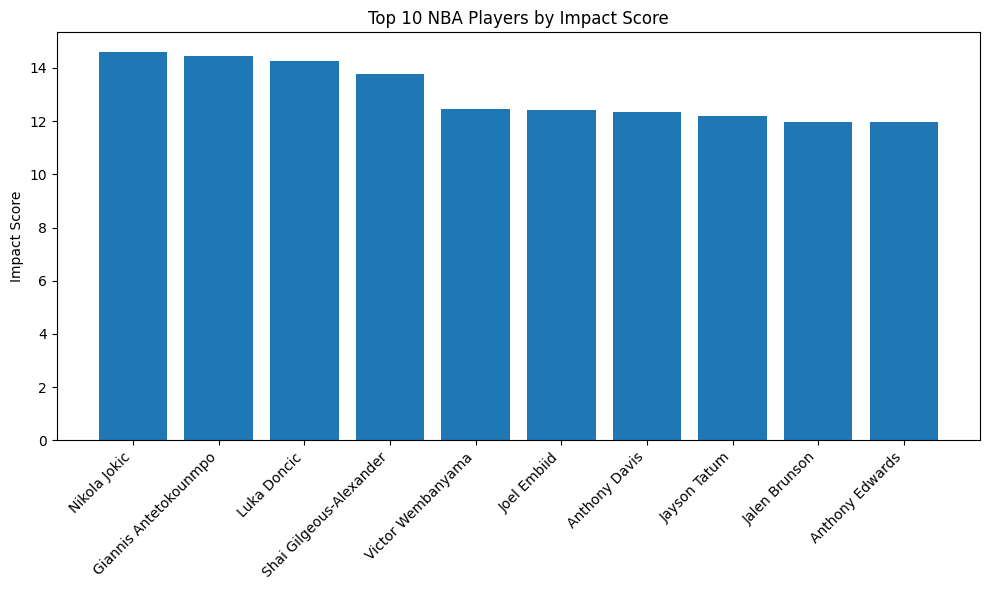

In [85]:
top10 = df.sort_values("impact_score", ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.bar(top10["playerName"], top10["impact_score"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Impact Score")
plt.title("Top 10 NBA Players by Impact Score")
plt.tight_layout()
plt.show()

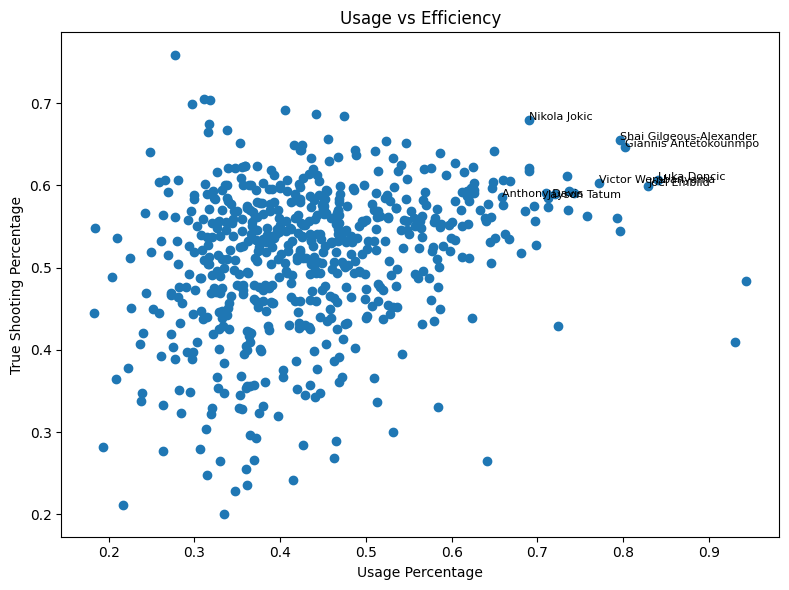

In [86]:
plt.figure(figsize=(8, 6))
plt.scatter(df["usg_pct"], df["ts_pct"])

for _, row in df.sort_values("impact_score", ascending=False).head(8).iterrows():
    plt.text(row["usg_pct"], row["ts_pct"], row["playerName"], fontsize=8)

plt.xlabel("Usage Percentage")
plt.ylabel("True Shooting Percentage")
plt.title("Usage vs Efficiency")
plt.tight_layout()
plt.show()

## 5. Reusable Leaderboards

To avoid writing the same sorting code over and over, I used a loop to generate multiple leaderboards automatically.

This makes the notebook easier to extend because new metrics can be added to the `stats_to_rank` list without rewriting the full ranking logic.


In [87]:
stats_to_rank = ["avg_fgm", "ts_pct", "usg_pct", "impact_score"]

for stat in stats_to_rank:
    print(f"\nTop 5 players by {stat}")
    print(df[["playerName", stat]].sort_values(stat, ascending=False).head(5))


Top 5 players by avg_fgm
                  playerName    avg_fgm
72     Giannis Antetokounmpo  11.358621
203  Shai Gilgeous-Alexander  10.846561
97              Nikola Jokic  10.607735
231              Luka Doncic  10.526316
197            Jalen Brunson   9.630435

Top 5 players by ts_pct
           playerName    ts_pct
589  Ryan Kalkbrenner  0.758036
569  Dereck Lively II  0.704382
479    Walker Kessler  0.704114
264      Jaxson Hayes  0.698931
276    Daniel Gafford  0.691648

Top 5 players by usg_pct
                playerName   usg_pct
142             Damion Lee  0.943793
570        Dariq Whitehead  0.930546
231            Luka Doncic  0.840937
90             Joel Embiid  0.829387
72   Giannis Antetokounmpo  0.801960

Top 5 players by impact_score
                  playerName  impact_score
97              Nikola Jokic     14.603384
72     Giannis Antetokounmpo     14.449574
231              Luka Doncic     14.272920
203  Shai Gilgeous-Alexander     13.761823
550        Victor Wemba

## 6. Predictive Modeling Extension

This section tests whether basic player features can help predict `pie`, an advanced all-around impact metric.

I used a simple linear regression model with:

- Average field goals made
- True shooting percentage
- Usage percentage

The purpose is not to build a perfect prediction model. The goal is to practice a clean modeling workflow: choosing features, splitting the data, scaling inputs, training a model, evaluating results, and interpreting feature weights.


### Modeling Setup

The next cells define the model inputs and target, create a train/test split, scale the features, train the regression model, and evaluate performance.


In [88]:
features = ["avg_fgm", "ts_pct", "usg_pct"]
target = "pie"

X = df[features]
y = df[target]

In [89]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [90]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [91]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [92]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred = model.predict(X_test_scaled)

r2 = r2_score(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("R²:", r2)
print("RMSE:", rmse)

R²: 0.9754231332982929
RMSE: 0.013270904071044228


In [93]:
coefficients = pd.DataFrame({
    "Feature": features,
    "Weight": model.coef_
})

print(coefficients)

   Feature    Weight
0  avg_fgm  0.087994
1   ts_pct  0.003280
2  usg_pct -0.008077


In [94]:
df["predicted_pie"] = model.predict(scaler.transform(df[features]))

top_predicted = df.sort_values("predicted_pie", ascending=False).head(10)
print(top_predicted[["playerName", "predicted_pie"]])

                  playerName  predicted_pie
72     Giannis Antetokounmpo       0.457674
203  Shai Gilgeous-Alexander       0.437447
97              Nikola Jokic       0.435586
231              Luka Doncic       0.419636
197            Jalen Brunson       0.390353
4               Kevin Durant       0.390001
32              Kyrie Irving       0.389708
315             Tyrese Maxey       0.386474
300          Anthony Edwards       0.378848
40             Kawhi Leonard       0.374543


## 7. Player Profile Extension

This section expands the project from player rankings into player profiles.

I added Basketball Reference shooting profile data to describe how players score, where they take shots from, and what type of offensive or defensive role they fit into. This turns the dataset into something more useful for a front-facing app because each player can now have a readable profile instead of only raw numbers.


### Name Cleaning for Player Matching

Player names can appear differently across data sources because of accents, punctuation, or encoding issues. I created a normalized player key so names can be matched more reliably across Kaggle and Basketball Reference data.


In [95]:
import unicodedata
import re

def fix_bref_name(name):
    if pd.isna(name):
        return ""

    name = str(name)

    # Fix Basketball Reference encoding issue like JokiÄ -> Jokić
    try:
        name = name.encode("latin1").decode("utf-8")
    except:
        pass

    return name


def make_player_key(name):
    if pd.isna(name):
        return ""

    name = fix_bref_name(name)
    name = name.lower().strip()

    # This is only for matching, not display
    name = unicodedata.normalize("NFKD", name)
    name = "".join(char for char in name if not unicodedata.combining(char))

    name = re.sub(r"[^a-z0-9\s]", "", name)
    name = " ".join(name.split())

    return name

### Adding Shooting Profile Data

Basketball Reference shooting splits are loaded from an `.xls` export. Even though the file extension is `.xls`, the table is read as HTML using `pd.read_html()`.

This section cleans the table, renames the columns, keeps the combined `TOT` row for players who changed teams, and merges the shooting profile features into the main player dataset.


In [96]:
import pandas as pd
import numpy as np
RAW_DIR = Path("/Users/Marcy_Student/Desktop/NBA project/data/raw")

# Load Basketball Reference shooting split file
# Basketball Reference downloads as .xls, but it is really an HTML table
shot_path = RAW_DIR / "shotprofile.xls"

print("Looking for:", shot_path.resolve())
print("File exists:", shot_path.exists())

if shot_path.exists():
    print("File size:", shot_path.stat().st_size, "bytes")

try:
    # Try Basketball Reference HTML-style .xls first
    shot_profile_raw = pd.read_html(str(shot_path))[0]
    print("Loaded shot profile with pd.read_html")
except ValueError:
    # If no HTML tables are found, try it as a real Excel file
    shot_profile_raw = pd.read_excel(shot_path)
    print("Loaded shot profile with pd.read_excel")

# Flatten multi-level columns from Basketball Reference
shot_profile_raw.columns = [
    "_".join([str(c) for c in col if "Unnamed" not in str(c)]).strip("_")
    if isinstance(col, tuple) else col
    for col in shot_profile_raw.columns
]

# Rename columns into cleaner names
shot_profile = shot_profile_raw.rename(columns={
    "Rk": "rk",
    "Player": "playerName",
    "Age": "age",
    "Team": "team",
    "Pos": "pos",
    "G": "games",
    "GS": "games_started",
    "MP": "minutes",
    "FG%": "fg_pct_total",
    "Dist.": "avg_shot_distance",

    "% of FGA by Distance_2P": "freq_2p",
    "% of FGA by Distance_0-3": "freq_rim",
    "% of FGA by Distance_3-10": "freq_short_paint",
    "% of FGA by Distance_10-16": "freq_mid",
    "% of FGA by Distance_16-3P": "freq_long_mid",
    "% of FGA by Distance_3P": "freq_3p",

    "FG% by Distance_2P": "fg_2p",
    "FG% by Distance_0-3": "fg_rim",
    "FG% by Distance_3-10": "fg_short_paint",
    "FG% by Distance_10-16": "fg_mid",
    "FG% by Distance_16-3P": "fg_long_mid",
    "FG% by Distance_3P": "fg_3p",

    "% of FG Ast'd_2P": "ast_2p",
    "% of FG Ast'd_3P": "ast_3p",

    "% of FGA_Dunks": "freq_dunk",
    "#_Dunks": "made_dunks",

    "% of 3PA_Corner": "freq_corner_3",
    "3P%_Corner": "fg_corner_3",

    "Heaves_Att.": "heave_attempts",
    "Heaves_Md.": "heave_makes"
})

# Keep only useful columns that exist
shot_cols = [
    "playerName", "team", "pos", "games", "minutes", "fg_pct_total", "avg_shot_distance",
    "freq_rim", "freq_short_paint", "freq_mid", "freq_long_mid", "freq_3p",
    "fg_rim", "fg_short_paint", "fg_mid", "fg_long_mid", "fg_3p",
    "freq_dunk", "made_dunks", "freq_corner_3", "fg_corner_3"
]

shot_cols = [col for col in shot_cols if col in shot_profile.columns]
shot_profile = shot_profile[shot_cols].copy()

# Remove repeated header rows if Basketball Reference added them
shot_profile = shot_profile[shot_profile["playerName"] != "Player"].copy()

# Convert numeric columns
for col in shot_profile.columns:
    if col != "playerName" and col != "team" and col != "pos":
        shot_profile[col] = pd.to_numeric(shot_profile[col], errors="coerce")
# --------------------------------------------------
# Keep only one row per player
# If a player has multiple teams, Basketball Reference gives:
# Team A row, Team B row, and TOT row.
# We want the combined TOT row.
# --------------------------------------------------

shot_profile["team"] = shot_profile["team"].astype(str)

# Create a priority column:
# TOT row gets priority 1, individual team rows get priority 2
shot_profile["team_priority"] = np.where(shot_profile["team"] == "TOT", 1, 2)

# Sort so TOT comes first for players with multiple rows
shot_profile = shot_profile.sort_values(
    by=["playerName", "team_priority"]
)

# Drop duplicate player names, keeping the TOT row when it exists
shot_profile = shot_profile.drop_duplicates(
    subset=["playerName"],
    keep="first"
)

# Remove helper column
shot_profile = shot_profile.drop(columns=["team_priority"])
# Clean names for merging
df["playerName_key"] = df["playerName"].apply(make_player_key)
shot_profile["playerName_key"] = shot_profile["playerName"].apply(make_player_key)

player_profiles = df.merge(
    shot_profile,
    on="playerName_key",
    how="left",
    suffixes=("", "_shooting")
)

def classify_defense_profile(row):
    pct_reb = row.get("pct_reb", 0)
    pct_blk = row.get("pct_blk", 0)
    pct_stl = row.get("pct_stl", 0)
    defensive_impact = row.get("defensive_impact", np.nan)

    reb_75 = player_profiles["pct_reb"].quantile(0.75) if "pct_reb" in player_profiles.columns else 0
    blk_75 = player_profiles["pct_blk"].quantile(0.75) if "pct_blk" in player_profiles.columns else 0
    stl_75 = player_profiles["pct_stl"].quantile(0.75) if "pct_stl" in player_profiles.columns else 0

    reb_60 = player_profiles["pct_reb"].quantile(0.60) if "pct_reb" in player_profiles.columns else 0
    blk_60 = player_profiles["pct_blk"].quantile(0.60) if "pct_blk" in player_profiles.columns else 0
    stl_60 = player_profiles["pct_stl"].quantile(0.60) if "pct_stl" in player_profiles.columns else 0

    if pct_blk >= blk_75 and pct_reb >= reb_60:
        return "Rim Protector"

    elif pct_reb >= reb_75 and pct_blk >= blk_60:
        return "Interior Defensive Anchor"

    elif pct_stl >= stl_75 and pct_blk >= blk_60:
        return "Disruptive Defender"

    elif pct_stl >= stl_75:
        return "Perimeter Ball Hawk"

    elif pct_reb >= reb_75:
        return "Strong Rebounding Defender"

    elif pct_blk >= blk_75:
        return "Shot Blocker"

    else:
        return "Neutral Defender"

def describe_defensive_profile(row):
    defense = row.get("defensive_profile", "Neutral Defender")

    if defense == "Rim Protector":
        return "Protects the basket with shot blocking and interior presence. This player is most valuable defensively near the rim."

    elif defense == "Interior Defensive Anchor":
        return "Controls the paint through rebounding, positioning, and rim protection. This player helps stabilize the defense inside."

    elif defense == "Disruptive Defender":
        return "Creates defensive pressure with steals, blocks, and activity. This player can force mistakes and break up possessions."

    elif defense == "Perimeter Ball Hawk":
        return "Applies pressure on the perimeter and creates steals. This player is active against guards and ball handlers."

    elif defense == "Strong Rebounding Defender":
        return "Finishes defensive possessions by securing rebounds. This player helps limit second-chance points."

    elif defense == "Shot Blocker":
        return "Provides value by challenging shots and blocking attempts, especially around the basket."

    else:
        return "Does not strongly stand out in one defensive category based on the available data."
# Keep the cleaner player name from your original data
player_profiles["playerName"] = player_profiles["playerName"]

Looking for: /Users/Marcy_Student/Desktop/NBA project/data/raw/shotprofile.xls
File exists: True
File size: 1077424 bytes
Loaded shot profile with pd.read_html


### Creating Player Archetypes

The next functions turn raw metrics into basketball-style descriptions. Instead of only showing numbers, the project labels players based on shot selection, efficiency, usage, playmaking, rebounding, and defensive activity.


In [97]:
def get_most_taken_shot(row):
    shot_freqs = {
        "at the rim": row.get("freq_rim", np.nan),
        "short paint / floater range": row.get("freq_short_paint", np.nan),
        "mid-range": row.get("freq_mid", np.nan),
        "long mid-range": row.get("freq_long_mid", np.nan),
        "three-point range": row.get("freq_3p", np.nan)
    }

    shot_freqs = {k: v for k, v in shot_freqs.items() if pd.notna(v)}

    if not shot_freqs:
        return "Not enough shooting data"

    return max(shot_freqs, key=shot_freqs.get)


def get_best_made_shot(row, min_frequency=0.08):
    shot_data = {
        "at the rim": {
            "freq": row.get("freq_rim", np.nan),
            "fg": row.get("fg_rim", np.nan)
        },
        "short paint / floater range": {
            "freq": row.get("freq_short_paint", np.nan),
            "fg": row.get("fg_short_paint", np.nan)
        },
        "mid-range": {
            "freq": row.get("freq_mid", np.nan),
            "fg": row.get("fg_mid", np.nan)
        },
        "long mid-range": {
            "freq": row.get("freq_long_mid", np.nan),
            "fg": row.get("fg_long_mid", np.nan)
        },
        "three-point range": {
            "freq": row.get("freq_3p", np.nan),
            "fg": row.get("fg_3p", np.nan)
        }
    }

    valid_shots = {
        shot: values
        for shot, values in shot_data.items()
        if pd.notna(values["freq"])
        and pd.notna(values["fg"])
        and values["freq"] >= min_frequency
    }

    if not valid_shots:
        return "Not enough shooting data"

    return max(valid_shots, key=lambda shot: valid_shots[shot]["fg"])


def classify_player_profile(row):
    rim_freq = row.get("freq_rim", 0)
    paint_freq = row.get("freq_short_paint", 0)
    mid_freq = row.get("freq_mid", 0) + row.get("freq_long_mid", 0)
    three_freq = row.get("freq_3p", 0)

    rim_fg = row.get("fg_rim", 0)
    mid_fg = np.nanmean([row.get("fg_mid", np.nan), row.get("fg_long_mid", np.nan)]) * 100
    three_fg = row.get("fg_3p", 0)

    ts_pct = row.get("ts_pct", 0)
    usg_pct = row.get("usg_pct", 0)
    pct_reb = row.get("pct_reb", 0)
    pct_ast = row.get("pct_ast", 0)
    pct_blk = row.get("pct_blk", 0)
    pct_stl = row.get("pct_stl", 0)
    impact_score = row.get("impact_score", 0)

    high_reb = pct_reb >= player_profiles["pct_reb"].quantile(0.70) if "pct_reb" in player_profiles.columns else False
    high_blk = pct_blk >= player_profiles["pct_blk"].quantile(0.70) if "pct_blk" in player_profiles.columns else False
    high_stl = pct_stl >= player_profiles["pct_stl"].quantile(0.70) if "pct_stl" in player_profiles.columns else False

    # Two-way / defensive profiles first
    if rim_freq >= 0.30 and rim_fg >= 0.62 and high_reb and high_blk:
        return "Rim-Dominant Two-Way Big"

    if three_freq >= 0.35 and three_fg >= 0.35 and high_stl:
        return "3-and-D Wing"

    if pct_ast >= player_profiles["pct_ast"].quantile(0.70) and high_stl:
        return "Two-Way Playmaker"

    # Offensive profiles
    if rim_freq >= 0.35 and rim_fg >= 0.65 and high_reb:
        return "Rim-Dominant Big"

    if rim_freq >= 0.30 and paint_freq >= 0.20 and three_freq < 0.20:
        return "Interior Paint Scorer"

    if three_freq >= 0.50 and three_fg >= 0.37:
        return "Elite 3PT Threat"

    if three_freq >= 0.40 and three_fg >= 0.35:
        return "Perimeter Shooter"

    if mid_freq >= 0.25 and mid_fg >= 0.43:
        return "Mid-Range Shot Creator"

    if rim_freq >= 0.20 and mid_freq >= 0.15 and three_freq >= 0.30 and ts_pct >= player_profiles["ts_pct"].median():
        return "Three-Level Scorer"

    if pct_ast >= player_profiles["pct_ast"].quantile(0.75) and usg_pct >= player_profiles["usg_pct"].median():
        return "On-Ball Creator"

    if ts_pct >= player_profiles["ts_pct"].quantile(0.75) and usg_pct < player_profiles["usg_pct"].median():
        return "Efficient Role Finisher"

    if usg_pct >= player_profiles["usg_pct"].quantile(0.75) and ts_pct < player_profiles["ts_pct"].median():
        return "Volume Shot Creator"

    if impact_score >= player_profiles["impact_score"].quantile(0.75):
        return "High-Impact Balanced Player"

    return "Balanced Player"


def describe_player_profile(row):
    profile = row["scorer_profile"]
    defense = row.get("defensive_profile", "Neutral Defender")
    most_taken = row["most_taken_shot"]
    best_shot = row["best_made_shot"]

    if profile == "Rim-Dominant Two-Way Big":
        return (
            f"{row['playerName']} profiles as a rim-dominant two-way big. "
            f"Offensively, they take most of their shots {most_taken} and finish best {best_shot}. "
            f"Defensively, they profile as a {defense}, meaning they impact the game with rebounding, shot blocking, and interior presence."
        )

    elif profile == "3-and-D Wing":
        return (
            f"{row['playerName']} profiles as a 3-and-D wing. "
            f"They provide value as a floor spacer with shots coming mostly from {most_taken}, while also bringing defensive activity as a {defense}."
        )

    elif profile == "Two-Way Playmaker":
        return (
            f"{row['playerName']} profiles as a two-way playmaker. "
            f"They create offense for themselves and others, but also show defensive activity as a {defense}. "
            f"Their most common shot comes {most_taken}, and their best scoring area is {best_shot}."
        )

    elif profile == "Rim-Dominant Big":
        return (
            f"{row['playerName']} profiles as a rim-dominant big. "
            f"They take a large share of their shots {most_taken}, finish best {best_shot}, "
            f"and their defensive profile as a {defense} suggests they impact the game around the basket."
        )

    elif profile == "Interior Paint Scorer":
        return (
            f"{row['playerName']} is mostly an interior paint scorer. "
            f"Their shot diet leans toward {most_taken}, and they are most reliable {best_shot}. "
            f"On defense, they profile as a {defense}."
        )

    elif profile == "Elite 3PT Threat":
        return (
            f"{row['playerName']} profiles as an elite 3PT threat. "
            f"They consistently take shots from {most_taken} and are most efficient {best_shot}. "
            f"Their defensive profile is {defense}."
        )

    elif profile == "Perimeter Shooter":
        return (
            f"{row['playerName']} is a perimeter shooter. "
            f"Their shot profile is built around {most_taken}, with their best efficiency coming {best_shot}. "
            f"Defensively, they profile as a {defense}."
        )

    elif profile == "Mid-Range Shot Creator":
        return (
            f"{row['playerName']} profiles as a mid-range shot creator. "
            f"They regularly look for shots from {most_taken}, while making shots most consistently {best_shot}. "
            f"On the defensive side, they profile as a {defense}."
        )

    elif profile == "Three-Level Scorer":
        return (
            f"{row['playerName']} profiles as a three-level scorer. "
            f"They have a balanced shot diet that includes rim attempts, mid-range looks, and threes. "
            f"Their most common shot comes {most_taken}, while their most reliable area is {best_shot}. "
            f"Defensively, they profile as a {defense}."
        )

    elif profile == "On-Ball Creator":
        return (
            f"{row['playerName']} profiles as an on-ball creator. "
            f"They combine scoring volume with creation stats, meaning they likely generate offense for themselves and others. "
            f"Defensively, they profile as a {defense}."
        )

    else:
        return (
            f"{row['playerName']} profiles as a balanced player. "
            f"Their most common shot comes {most_taken}, and they make shots most consistently {best_shot}. "
            f"On defense, they profile as a {defense}."
        )

In [98]:
player_profiles["defensive_profile"] = player_profiles.apply(classify_defense_profile, axis=1)
player_profiles["most_taken_shot"] = player_profiles.apply(get_most_taken_shot, axis=1)
player_profiles["best_made_shot"] = player_profiles.apply(get_best_made_shot, axis=1)
player_profiles["scorer_profile"] = player_profiles.apply(classify_player_profile, axis=1)
player_profiles["profile_description"] = player_profiles.apply(describe_player_profile, axis=1)
player_profiles["defensive_profile"] = player_profiles.apply(classify_defense_profile, axis=1)
player_profiles["defensive_description"] = player_profiles.apply(describe_defensive_profile, axis=1)

player_profiles[[
    "playerName",
    "games_played",
    "avg_fgm",
    "ts_pct",
    "usg_pct",
    "pct_reb",
    "pct_ast",
    "most_taken_shot",
    "best_made_shot",
    "scorer_profile",
    "profile_description"
]].head()

/var/folders/61/74kg9mdn59bgmqnp34mpmrkr0000gp/T/ipykernel_80281/153226691.py:63: RuntimeWarning: Mean of empty slice
  mid_fg = np.nanmean([row.get("fg_mid", np.nan), row.get("fg_long_mid", np.nan)]) * 100
/var/folders/61/74kg9mdn59bgmqnp34mpmrkr0000gp/T/ipykernel_80281/153226691.py:63: RuntimeWarning: Mean of empty slice
  mid_fg = np.nanmean([row.get("fg_mid", np.nan), row.get("fg_long_mid", np.nan)]) * 100
/var/folders/61/74kg9mdn59bgmqnp34mpmrkr0000gp/T/ipykernel_80281/153226691.py:63: RuntimeWarning: Mean of empty slice
  mid_fg = np.nanmean([row.get("fg_mid", np.nan), row.get("fg_long_mid", np.nan)]) * 100
/var/folders/61/74kg9mdn59bgmqnp34mpmrkr0000gp/T/ipykernel_80281/153226691.py:63: RuntimeWarning: Mean of empty slice
  mid_fg = np.nanmean([row.get("fg_mid", np.nan), row.get("fg_long_mid", np.nan)]) * 100
/var/folders/61/74kg9mdn59bgmqnp34mpmrkr0000gp/T/ipykernel_80281/153226691.py:63: RuntimeWarning: Mean of empty slice
  mid_fg = np.nanmean([row.get("fg_mid", np.nan), row.

,playerName,games_played,avg_fgm,ts_pct,usg_pct,pct_reb,pct_ast,most_taken_shot,best_made_shot,scorer_profile,profile_description
0,LeBron James,169,8.917160,0.605203,0.667977,0.204113,0.235394,at the rim,at the rim,On-Ball Creator,LeBron James profiles as an on-ball creator. T...
1,Chris Paul,125,2.976000,0.558598,0.345439,0.135565,0.255924,Not enough shooting data,Not enough shooting data,Balanced Player,Chris Paul profiles as a balanced player. Thei...
2,Kyle Lowry,81,1.481481,0.432806,0.283606,0.097878,0.142033,Not enough shooting data,Not enough shooting data,Balanced Player,Kyle Lowry profiles as a balanced player. Thei...
3,Kevin Durant,187,9.459893,0.641500,0.649684,0.165103,0.124333,three-point range,short paint / floater range,Mid-Range Shot Creator,Kevin Durant profiles as a mid-range shot crea...
4,Al Horford,143,3.286713,0.585073,0.338309,0.227649,0.091730,three-point range,at the rim,Perimeter Shooter,Al Horford is a perimeter shooter. Their shot ...


### Interactive Player Lookup

This section lets a user search for a player by name. I used fuzzy matching so the search can still work when the input has a typo, missing accent, or slightly different spelling.


In [99]:
from rapidfuzz import process, fuzz

player_profiles["playerName_key"] = player_profiles["playerName"].apply(make_player_key)

player_input = make_player_key(input("Enter a player name: "))

try:
    result = player_profiles[player_profiles["playerName_key"] == player_input]

    if result.empty:
        choices = player_profiles["playerName_key"].dropna().unique().tolist()

        match = process.extractOne(
            player_input,
            choices,
            scorer=fuzz.WRatio,
            score_cutoff=80
        )

        if match:
            best_match = match[0]
            result = player_profiles[player_profiles["playerName_key"] == best_match]
            print(f"Showing closest match: {result.iloc[0]['playerName']}")
        else:
            raise ValueError("Player not found in dataset.")

    player = result.iloc[0]

    print("=" * 60)
    print(f"PLAYER PROFILE: {player['playerName']}")
    print("=" * 60)

    print("\nBasic Stats")
    print(f"Games Played: {player['games_played']}")
    print(f"Avg FGM: {player['avg_fgm']:.2f}")
    print(f'Avg Shot Distance: {player['avg_shot_distance']:.2f} ft')
    print(f"True Shooting %: {player['ts_pct']:.3f}")
    print(f"Usage %: {player['usg_pct']*100:.3f}")
    print(f"Impact Score: {player['impact_score']:.2f}")

    print("\nShot Profile")
    print(f"Most Taken Shot Area: {player['most_taken_shot']}")
    print(f"Most Efficient Shot Area: {player['best_made_shot']}")
    print(f"Scorer Profile: {player['scorer_profile']}")

    print("\nPlayer Type")
    print(f"Overall Profile: {player['scorer_profile']}")
    print(f"Defensive Profile: {player['defensive_profile']}")
    
    print("\nDescription")
    print(player["profile_description"])
    print(f"Defensive Description: {player['defensive_description']}")

    print("\nShot Frequency")
    shot_freq_table = pd.DataFrame({
        "Shot Area": [
            "At Rim",
            "Short Paint",
            "Mid-Range",
            "Long Mid-Range",
            "3PT"
        ],
        "Frequency": [
            player.get("freq_rim", np.nan) * 100,
            player.get("freq_short_paint", np.nan) * 100,
            player.get("freq_mid", np.nan) * 100,
            player.get("freq_long_mid", np.nan) * 100,
            player.get("freq_3p", np.nan) * 100
        ],
        "FG%": [
            player.get("fg_rim", np.nan) * 100,
            player.get("fg_short_paint", np.nan) * 100,
            player.get("fg_mid", np.nan) * 100,
            player.get("fg_long_mid", np.nan) * 100,
            player.get("fg_3p", np.nan) * 100
        ]
    })

    display(shot_freq_table)

except ValueError as e:
    print("Error:", e)

Showing closest match: Jayson Tatum
PLAYER PROFILE: Jayson Tatum

Basic Stats
Games Played: 132
Avg FGM: 8.89
Avg Shot Distance: 16.80 ft
True Shooting %: 0.585
Usage %: 71.178
Impact Score: 12.20

Shot Profile
Most Taken Shot Area: three-point range
Most Efficient Shot Area: at the rim
Scorer Profile: On-Ball Creator

Player Type
Overall Profile: On-Ball Creator
Defensive Profile: Rim Protector

Description
Jayson Tatum profiles as an on-ball creator. They combine scoring volume with creation stats, meaning they likely generate offense for themselves and others. Defensively, they profile as a Rim Protector.
Defensive Description: Protects the basket with shot blocking and interior presence. This player is most valuable defensively near the rim.

Shot Frequency


,Shot Area,Frequency,FG%
0,At Rim,17.1,69.4
1,Short Paint,16.7,39.6
2,Mid-Range,9.8,46.4
3,Long Mid-Range,6.6,26.3
4,3PT,49.8,32.9


### Individual Shot Profile Chart

After a player is selected, this chart shows where that player takes most of their shots.


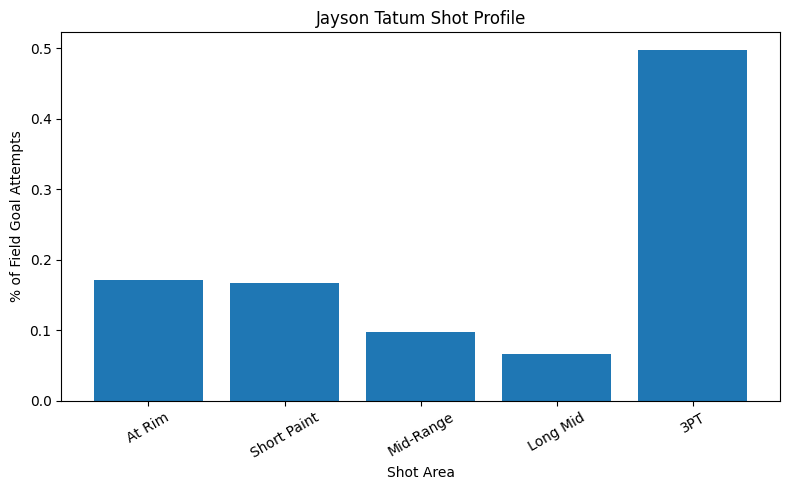

In [100]:
areas = ["At Rim", "Short Paint", "Mid-Range", "Long Mid", "3PT"]
freqs = [
    player.get("freq_rim", np.nan),
    player.get("freq_short_paint", np.nan),
    player.get("freq_mid", np.nan),
    player.get("freq_long_mid", np.nan),
    player.get("freq_3p", np.nan)
]

if all(pd.isna(freq) for freq in freqs):
    print(f"No shooting profile data found for {player['playerName']}.")


plt.figure(figsize=(8, 5))
plt.bar(areas, freqs)
plt.title(f"{player['playerName']} Shot Profile")
plt.ylabel("% of Field Goal Attempts")
plt.xlabel("Shot Area")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

# Part 3: Play-by-Play Data + Streamlit App Features

The final part of the notebook prepares the dataset for the Streamlit version of the project.

Here, I add play-by-play style features, create lineup scoring columns, assign players into lineup roles, and export the final player profile dataset used by the app.


## 8. Loading Play-by-Play Style Data

This section loads the Basketball Reference play-by-play export. These columns add more context around position estimates, on/off impact, turnovers, points generated by assists, and other supporting stats.


In [101]:
import pandas as pd
import numpy as np

pbp_path = RAW_DIR / 'pbp.xls'

pbp_raw = pd.read_html(pbp_path)[0]

# Flatten Basketball Reference multi-level columns
pbp_raw.columns = [
    "_".join([str(c) for c in col if "Unnamed" not in str(c)]).strip("_")
    if isinstance(col, tuple) else col
    for col in pbp_raw.columns
]

pbp = pbp_raw.copy()

pbp.head()

,Rk,Player,Age,Team,Pos,G,GS,MP,Position Estimate_PG%,Position Estimate_SG%,...,Turnovers_BadPass,Turnovers_LostBall,Fouls Committed_Shoot,Fouls Committed_Off.,Fouls Drawn_Shoot,Fouls Drawn_Off.,Misc._PGA,Misc._And1,Misc._Blkd,Awards
0,1,Amen Thompson,23,HOU,PG,79,79,2953,83,16,...,92,72,80,14,191,12,1040,51,68,DPOY-8
1,2,Kevin Durant,37,HOU,SF,78,78,2840,0,32,...,136,81,80,21,162,2,847,38,41,"CPOY-9,AS,NBA2"
2,3,Desmond Bane,27,ORL,SG,82,82,2756,2,69,...,79,48,119,19,128,7,817,37,82,NaN
3,4,Toumani Camara,25,POR,PF,82,82,2731,0,0,...,92,38,111,8,57,106,508,12,44,NaN
4,5,Jabari Smith Jr.,22,HOU,PF,77,77,2705,0,0,...,39,40,94,14,89,8,352,15,53,NaN


In [102]:
pbp = pbp.rename(columns={
    "Rk": "rk",
    "Player": "playerName_pbp",
    "Age": "age_pbp",
    "Team": "team_pbp",
    "Pos": "pos_pbp",
    "G": "games_pbp",
    "GS": "games_started_pbp",
    "MP": "minutes_pbp",

    "Position Estimate_PG%": "pg_pct",
    "Position Estimate_SG%": "sg_pct",
    "Position Estimate_SF%": "sf_pct",
    "Position Estimate_PF%": "pf_pct",
    "Position Estimate_C%": "c_pct",

    "+/- Per 100 Poss_OnCourt": "on_court_per_100",
    "+/- Per 100 Poss_On-Off": "on_off_per_100",

    "Turnovers_BadPass": "bad_pass_turnovers",
    "Turnovers_LostBall": "lost_ball_turnovers",

    "Misc._PGA": "points_generated_by_assists",
    "Misc._And1": "and_ones",
    "Misc._Blkd": "shots_blocked_against",

    "Awards": "awards"
})

# Remove repeated header rows
pbp = pbp[pbp["playerName_pbp"] != "Player"].copy()

# Convert number columns
for col in pbp.columns:
    if col not in ["playerName_pbp", "team_pbp", "pos_pbp", "awards"]:
        pbp[col] = pd.to_numeric(pbp[col], errors="coerce")

# Create matching key using the same function from earlier
pbp["playerName_key"] = pbp["playerName_pbp"].apply(make_player_key)

In [103]:
pbp["team_pbp"] = pbp["team_pbp"].astype(str)

pbp["team_priority"] = np.where(
    pbp["team_pbp"].isin(["TOT", "2TM", "3TM", "4TM"]),
    1,
    2
)

pbp = pbp.sort_values(
    by=["playerName_key", "team_priority"]
)

pbp = pbp.drop_duplicates(
    subset=["playerName_key"],
    keep="first"
)

pbp = pbp.drop(columns=["team_priority"])

In [104]:
player_profiles = player_profiles.merge(
    pbp,
    on="playerName_key",
    how="left"
)

## 9. Feature Engineering for Lineup Scoring

The Streamlit app needs one final player-level table with features that can support lineup comparison.

The next cells create values for:

- Offensive creation
- Defensive impact
- Spacing
- Playmaking
- Rebounding
- Overall lineup score


In [105]:
possible_points_cols = ["avg_pts", "points", "pts", "PTS", "ppg"]

points_col = None

for col in possible_points_cols:
    if col in player_profiles.columns:
        points_col = col
        break

if points_col:
    player_profiles["scoring_value"] = player_profiles[points_col]
else:
    player_profiles["scoring_value"] = player_profiles["avg_fgm"] * 2

player_profiles["points_generated_by_assists"] = (
    player_profiles["points_generated_by_assists"].fillna(0)
)

player_profiles["offensive_creation"] = (
    player_profiles["scoring_value"] +
    player_profiles["points_generated_by_assists"]
)

In [106]:
def get_col_or_zero(df, col):
    if col in df.columns:
        return df[col].fillna(0)
    return 0


player_profiles["lineup_defensive_impact"] = (
    get_col_or_zero(player_profiles, "pct_reb") * 0.30 +
    get_col_or_zero(player_profiles, "pct_blk") * 0.30 +
    get_col_or_zero(player_profiles, "pct_stl") * 0.25 +
    get_col_or_zero(player_profiles, "on_off_per_100") * 0.15
)

In [107]:
# Spacing: use 3PT shot frequency if available
player_profiles["spacing_value"] = get_col_or_zero(player_profiles, "freq_3p")

# Playmaking: use points generated by assists
player_profiles["playmaking_value"] = player_profiles["points_generated_by_assists"]

# Rebounding / size
player_profiles["rebounding_value"] = get_col_or_zero(player_profiles, "pct_reb")
player_profiles["rim_size_value"] = get_col_or_zero(player_profiles, "c_pct")

In [108]:
def min_max_scale(series):
    series = series.fillna(0)

    if series.max() == series.min():
        return series * 0

    return (series - series.min()) / (series.max() - series.min())


player_profiles["offense_scaled"] = min_max_scale(player_profiles["offensive_creation"])
player_profiles["defense_scaled"] = min_max_scale(player_profiles["lineup_defensive_impact"])
player_profiles["spacing_scaled"] = min_max_scale(player_profiles["spacing_value"])
player_profiles["playmaking_scaled"] = min_max_scale(player_profiles["playmaking_value"])
player_profiles["rebounding_scaled"] = min_max_scale(player_profiles["rebounding_value"])

In [109]:
player_profiles["lineup_score"] = (
    player_profiles["offense_scaled"] * 0.40 +
    player_profiles["defense_scaled"] * 0.25 +
    player_profiles["spacing_scaled"] * 0.15 +
    player_profiles["playmaking_scaled"] * 0.10 +
    player_profiles["rebounding_scaled"] * 0.10
)

## 10. Assigning Lineup Roles

To make lineup building more realistic, players are grouped into simple roles:

- Guards
- Wings
- Bigs

This allows the app to build or compare balanced lineups instead of only selecting the top five players by score.


In [110]:
def assign_lineup_role(row):
    guard_score = row.get("pg_pct", 0) + row.get("sg_pct", 0)
    wing_score = row.get("sf_pct", 0) + row.get("pf_pct", 0)
    big_score = row.get("c_pct", 0)

    if big_score >= guard_score and big_score >= wing_score:
        return "Big"
    elif guard_score >= wing_score:
        return "Guard"
    else:
        return "Wing"


player_profiles["lineup_role"] = player_profiles.apply(assign_lineup_role, axis=1)

In [111]:
def get_best_balanced_lineup(player_profiles):
    guards = (
        player_profiles[player_profiles["lineup_role"] == "Guard"]
        .sort_values("lineup_score", ascending=False)
        .head(2)
    )

    wings = (
        player_profiles[player_profiles["lineup_role"] == "Wing"]
        .sort_values("lineup_score", ascending=False)
        .head(2)
    )

    bigs = (
        player_profiles[player_profiles["lineup_role"] == "Big"]
        .sort_values("lineup_score", ascending=False)
        .head(1)
    )

    best_lineup = pd.concat([guards, wings, bigs])

    return best_lineup.sort_values("lineup_score", ascending=False)


best_5_lineup = get_best_balanced_lineup(player_profiles)

best_5_lineup[[
    "playerName",
    "lineup_role",
    "scorer_profile",
    "defensive_profile",
    "offensive_creation",
    "points_generated_by_assists",
    "lineup_defensive_impact",
    "lineup_score"
]]

,playerName,lineup_role,scorer_profile,defensive_profile,offensive_creation,points_generated_by_assists,lineup_defensive_impact,lineup_score
87,Nikola Jokic,Big,On-Ball Creator,Rim Protector,1676.215470,1655.0,2.132835,0.809221
351,Cade Cunningham,Guard,On-Ball Creator,Disruptive Defender,1494.024390,1476.0,0.935319,0.685465
259,LaMelo Ball,Guard,Perimeter Shooter,Disruptive Defender,1278.306452,1263.0,0.993987,0.668217
329,Jalen Johnson,Wing,On-Ball Creator,Rim Protector,1393.424658,1378.0,0.444633,0.641290
372,Dyson Daniels,Wing,Interior Paint Scorer,Rim Protector,1104.245810,1094.0,1.736778,0.583998


In [112]:
print("=" * 70)
print("BEST BALANCED 5-MAN LINEUP")
print("=" * 70)

for i, player in best_5_lineup.reset_index(drop=True).iterrows():
    print(f"\n{i + 1}. {player['playerName']} — {player['lineup_role']}")
    print(f"Scorer Profile: {player.get('scorer_profile', 'N/A')}")
    print(f"Defensive Profile: {player.get('defensive_profile', 'N/A')}")
    print(f"Offensive Creation: {player['offensive_creation']:.2f}")
    print(f"Points Generated by Assists: {player['points_generated_by_assists']:.0f}")
    print(f"Defensive Impact: {player['lineup_defensive_impact']:.2f}")
    print(f"Lineup Score: {player['lineup_score']:.3f}")

print("\nLineup Summary:")
print(
    "This lineup is selected using a balanced structure of 2 guards, 2 wings, and 1 big. "
    "The score prioritizes scoring and points created through assists, then adds defensive impact, "
    "spacing, playmaking, and rebounding."
)

BEST BALANCED 5-MAN LINEUP

1. Nikola Jokic — Big
Scorer Profile: On-Ball Creator
Defensive Profile: Rim Protector
Offensive Creation: 1676.22
Points Generated by Assists: 1655
Defensive Impact: 2.13
Lineup Score: 0.809

2. Cade Cunningham — Guard
Scorer Profile: On-Ball Creator
Defensive Profile: Disruptive Defender
Offensive Creation: 1494.02
Points Generated by Assists: 1476
Defensive Impact: 0.94
Lineup Score: 0.685

3. LaMelo Ball — Guard
Scorer Profile: Perimeter Shooter
Defensive Profile: Disruptive Defender
Offensive Creation: 1278.31
Points Generated by Assists: 1263
Defensive Impact: 0.99
Lineup Score: 0.668

4. Jalen Johnson — Wing
Scorer Profile: On-Ball Creator
Defensive Profile: Rim Protector
Offensive Creation: 1393.42
Points Generated by Assists: 1378
Defensive Impact: 0.44
Lineup Score: 0.641

5. Dyson Daniels — Wing
Scorer Profile: Interior Paint Scorer
Defensive Profile: Rim Protector
Offensive Creation: 1104.25
Points Generated by Assists: 1094
Defensive Impact: 1.7

## 12. Quick Data Checks

Before exporting the final dataset, I inspected the play-by-play table to confirm the imported columns and row structure.


In [113]:
pbp_test = pd.read_html(RAW_DIR / 'pbp.xls')[0]

pbp_test.columns = [
    "_".join([str(c) for c in col if "Unnamed" not in str(c)]).strip("_")
    if isinstance(col, tuple) else col
    for col in pbp_test.columns
]

pbp_test.head()

,Rk,Player,Age,Team,Pos,G,GS,MP,Position Estimate_PG%,Position Estimate_SG%,...,Turnovers_BadPass,Turnovers_LostBall,Fouls Committed_Shoot,Fouls Committed_Off.,Fouls Drawn_Shoot,Fouls Drawn_Off.,Misc._PGA,Misc._And1,Misc._Blkd,Awards
0,1,Amen Thompson,23,HOU,PG,79,79,2953,83,16,...,92,72,80,14,191,12,1040,51,68,DPOY-8
1,2,Kevin Durant,37,HOU,SF,78,78,2840,0,32,...,136,81,80,21,162,2,847,38,41,"CPOY-9,AS,NBA2"
2,3,Desmond Bane,27,ORL,SG,82,82,2756,2,69,...,79,48,119,19,128,7,817,37,82,NaN
3,4,Toumani Camara,25,POR,PF,82,82,2731,0,0,...,92,38,111,8,57,106,508,12,44,NaN
4,5,Jabari Smith Jr.,22,HOU,PF,77,77,2705,0,0,...,39,40,94,14,89,8,352,15,53,NaN


In [114]:
pbp_test.columns

Index(['Rk', 'Player', 'Age', 'Team', 'Pos', 'G', 'GS', 'MP',
       'Position Estimate_PG%', 'Position Estimate_SG%',
       'Position Estimate_SF%', 'Position Estimate_PF%',
       'Position Estimate_C%', '+/- Per 100 Poss_OnCourt',
       '+/- Per 100 Poss_On-Off', 'Turnovers_BadPass', 'Turnovers_LostBall',
       'Fouls Committed_Shoot', 'Fouls Committed_Off.', 'Fouls Drawn_Shoot',
       'Fouls Drawn_Off.', 'Misc._PGA', 'Misc._And1', 'Misc._Blkd', 'Awards'],
      dtype='object')

In [115]:
pbp_test.tail()

,Rk,Player,Age,Team,Pos,G,GS,MP,Position Estimate_PG%,Position Estimate_SG%,...,Turnovers_BadPass,Turnovers_LostBall,Fouls Committed_Shoot,Fouls Committed_Off.,Fouls Drawn_Shoot,Fouls Drawn_Off.,Misc._PGA,Misc._And1,Misc._Blkd,Awards
494,390,Jeremy Sochan,22,SAS,PF,28,0,358,0,0,...,7,5,21,4,5,2,72,2,8,NaN
495,390,Jeremy Sochan,22,NYK,PF,16,0,111,0,0,...,1,2,4,0,5,0,29,0,1,NaN
496,391,Maxi Kleber,34,LAL,PF,43,1,461,0,0,...,9,2,35,6,11,1,71,0,6,NaN
497,392,Marcus Sasser,25,DET,PG,38,5,457,100,0,...,21,7,23,1,7,1,183,1,8,NaN
498,393,AJ Johnson,21,2TM,SG,48,0,454,30,60,...,15,6,18,2,20,0,113,4,24,NaN


## 13. Exporting the Final App Dataset

The final output is `player_profiles_final.csv`, which becomes the main dataset used by the Streamlit app.


In [117]:
player_profiles.to_csv(PROCESSED_DIR / 'player_profiles_final.csv', index=False)
print('Saved to:', PROCESSED_DIR / 'player_profiles_final.csv')

Saved to: /Users/Marcy_Student/Desktop/NBA project/notebooks/data/processed/player_profiles_final.csv
